In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [3]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [4]:
tmp = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/denali/testdenali/All/alltiles_Allzinfo.fits', columns=['SV1_DESI_TARGET', 'TARGETS', 'coadd_type']))
mask = (tmp['SV1_DESI_TARGET'] & 2**0 > 0) & (tmp['TARGETS']=='QSO+LRG') & (tmp['coadd_type']=='cumulative')
idx = np.where(mask)[0]
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/denali/testdenali/All/alltiles_Allzinfo.fits', rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

52268
52023


In [5]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

FIBERSTATUS 43371 8897 0.17021887196755184
No data 43368 3 6.917064397869545e-05


In [6]:
# Require a minimum depth for the deep coadd
min_depth = 3000.
mask = zbest['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

Min depth 31466 11902 0.7255580151263604
31466
31408


In [7]:
# Remove duplicates
_, idx = np.unique(zbest['TARGETID'], return_index=True)
zbest = zbest[idx]
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

31408
31408


In [8]:
# Ting-Wen's quality cuts
mask = zbest['ZWARN']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
mask &= zbest['Z']<1.4
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
mask &= zbest['DELTACHI2']>20
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]
print(len(zbest))

Quality cuts 31154 254 0.9919128884360673
Quality cuts 30802 606 0.9807055527254203
Quality cuts 30619 789 0.9748790117167601
30619


In [9]:
# Remove stars
mask_star = (zbest['SPECTYPE']=='STAR') | (zbest['Z']<0.0003)
zbest = zbest[~mask_star]
print(len(zbest))

29850


__Add MEDIUM and WISE masks and require NOBS>=2__

In [10]:
maskbits = [1, 8, 11, 12, 13]
min_nobs = 2

mask_clean = np.ones(len(zbest), dtype=bool)
for bit in maskbits:
    mask_clean &= (zbest['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))

# mask_clean &= (zbest['NOBS_G']>=min_nobs) & (zbest['NOBS_R']>=min_nobs) & (zbest['NOBS_Z']>=min_nobs)
# print(np.sum(~mask_clean)/len(mask_clean))

zbest = zbest[mask_clean]

0.06921273031825796


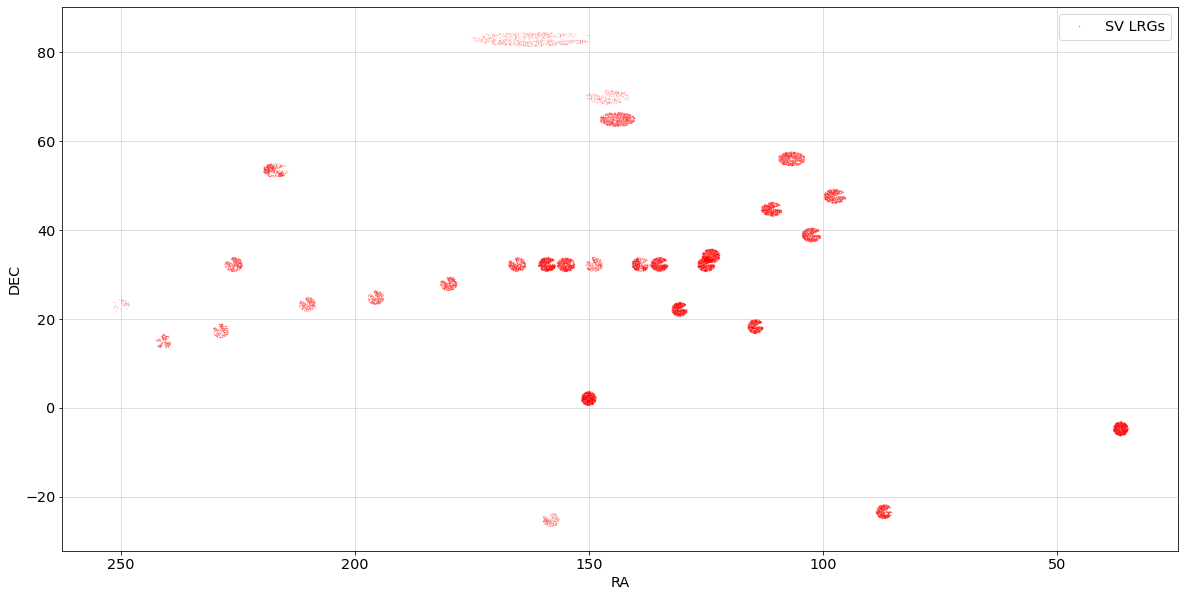

In [11]:
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'], zbest['TARGET_DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [12]:
tmp = fitsio.read('/global/cfs/cdirs/desi/spectro/fastspecfit/denali/tiles/merged/fastphot-denali-cumulative.fits', columns=['TARGETID'])
idx = np.where(np.in1d(tmp['TARGETID'], zbest['TARGETID']))[0]
print(len(idx)/len(tmp))
cat = Table(fitsio.read('/global/cfs/cdirs/desi/spectro/fastspecfit/denali/tiles/merged/fastphot-denali-cumulative.fits', rows=idx))
print(len(cat))

0.06929817994779153
28697


In [13]:
zbest = join(zbest, cat, keys='TARGETID', join_type='inner')
len(zbest)

28697

In [14]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']) - 3.214 * zbest['EBV']
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']) - 2.165 * zbest['EBV']
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']) - 1.211 * zbest['EBV']
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']) - 0.184 * zbest['EBV']
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']) - 0.113 * zbest['EBV']
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']) - 3.214 * zbest['EBV']
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']) - 2.165 * zbest['EBV']
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']) - 1.211 * zbest['EBV']
    
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [15]:
# zfiber & sliding cut extension; 800 targets/sq.deg.

# mask_north = zbest['PHOTSYS']=='N'
# mask_south = zbest['PHOTSYS']=='S'

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.26) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.36) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.29
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.3) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.13)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.72)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.24) * 1.83 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.34) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.23)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_north = lrg_mask.copy()

lrg_sv3 = lrg_sv3_south | lrg_sv3_north
print(np.sum(lrg_sv3))

10791


In [16]:
lrg_sv3_800 = lrg_sv3.copy()
lrg_sv3_south_800 = lrg_sv3_south.copy()
lrg_sv3_north_800 = lrg_sv3_north.copy()

In [17]:
# rspec = 22.5 - 2.5*np.log10(zbest['FLUX_SYNTH_R']) - 2.165 * zbest['EBV']
# zspec = 22.5 - 2.5*np.log10(zbest['FLUX_SYNTH_Z']) - 2.165 * zbest['EBV']

# rspecmodel = 22.5 - 2.5*np.log10(zbest['FLUX_SYNTH_MODEL_R']) - 2.165 * zbest['EBV']
# zspecmodel = 22.5 - 2.5*np.log10(zbest['FLUX_SYNTH_MODEL_Z']) - 2.165 * zbest['EBV']

# plt.hist(rspec-rmag, 100, range=(-2, 2))
# plt.grid()
# plt.show()

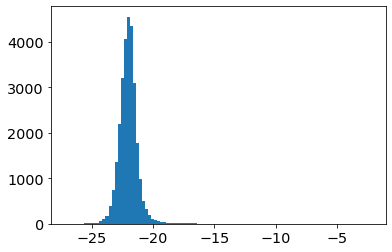

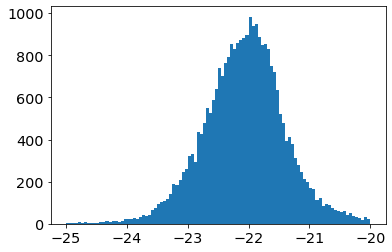

In [22]:
plt.hist(zbest['ABSMAG_G'], 100)
plt.show()

plt.hist(zbest['ABSMAG_G'], 100, range=(-25, -20))
plt.show()

(0.2, 2.8, -0.0, 3.0)

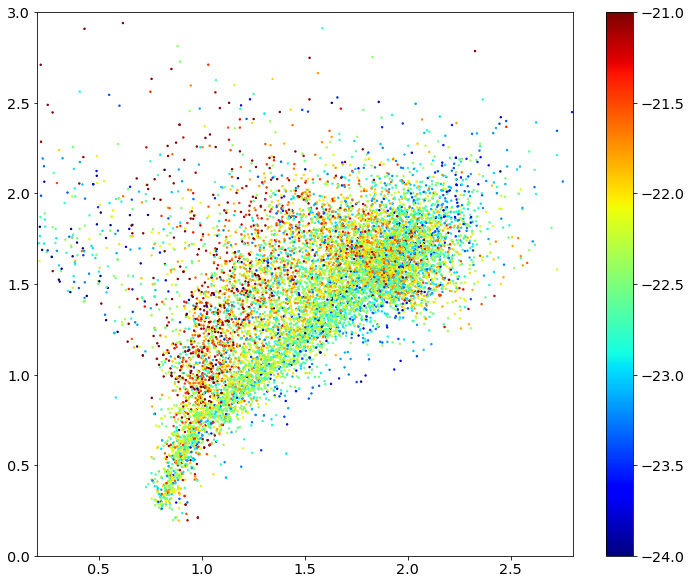

In [48]:
plt.figure(figsize=(12, 10))
plt.scatter((rmag-zmag)[lrg_sv3], (zmag-w1mag)[lrg_sv3], c=zbest['ABSMAG_G'][lrg_sv3], s=2, vmin=-24, vmax=-21,
           cmap='jet')
plt.colorbar()
plt.axis([0.2, 2.8, -0., 3.])

(0.2, 2.8, -0.0, 3.0)

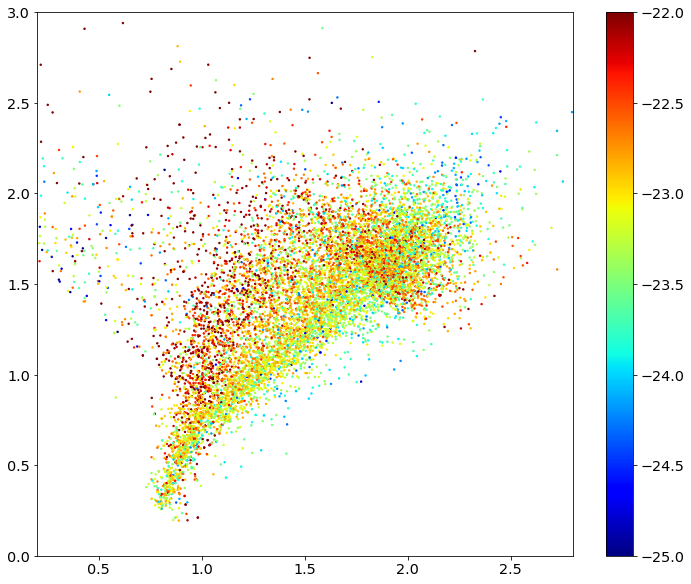

In [49]:
plt.figure(figsize=(12, 10))
plt.scatter((rmag-zmag)[lrg_sv3], (zmag-w1mag)[lrg_sv3], c=zbest['ABSMAG_R'][lrg_sv3], s=2, vmin=-25, vmax=-22,
           cmap='jet')
plt.colorbar()
plt.axis([0.2, 2.8, -0., 3.])

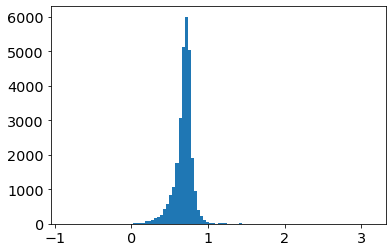

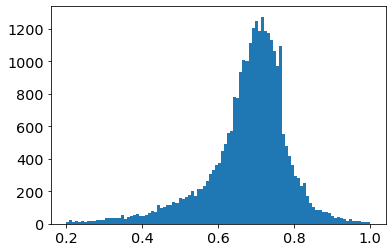

In [36]:
plt.hist(zbest['ABSMAG_G']-zbest['ABSMAG_R'], 100)
plt.show()

plt.hist(zbest['ABSMAG_G']-zbest['ABSMAG_R'], 100, range=(0.2, 1))
plt.show()

(0.2, 2.8, -0.0, 3.0)

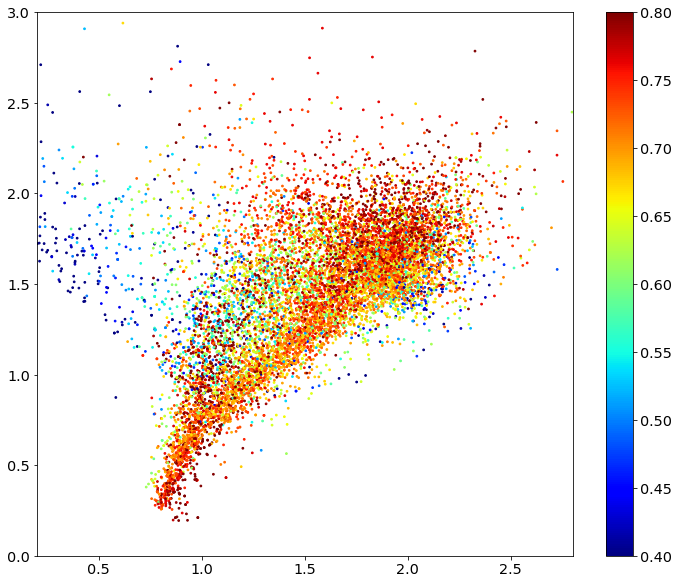

In [59]:
plt.figure(figsize=(12, 10))
plt.scatter((rmag-zmag)[lrg_sv3], (zmag-w1mag)[lrg_sv3], c=(zbest['ABSMAG_G']-zbest['ABSMAG_R'])[lrg_sv3], s=3,
            vmin=0.4, vmax=0.8, cmap='jet')
plt.colorbar()
plt.axis([0.2, 2.8, -0., 3.])